# Predicting Credit Card Default

**ADS-504 Group 6 — Final Project**

Cameron Moran, Daniel Lopez, and Francisco Hernandez

Dataset: *Default of Credit Card Clients* (UCI) — 30,000 clients of a Taiwanese credit
card issuer, April–September 2005, 23 predictors and a binary default outcome.

This notebook is the complete analysis: exploratory data analysis, pre-processing,
feature engineering, model comparison, validation, and final evaluation. It runs
top-to-bottom in Google Colab with no setup — the data is read directly from the project
repository.

**Contents**

1. Data loading and initial inspection
2. Exploratory data analysis
3. Pre-processing
4. Feature engineering
5. Modeling setup
6. Model comparison and validation
7. Results
8. Final model evaluation
9. Feature ranking
10. Findings

## 1. Data loading and initial inspection

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, average_precision_score,
                             classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
pd.set_option("display.width", 200, "display.max_columns", 60)

# Colorblind-safe pair used for every two-series chart in this notebook
BLUE, ORANGE, INK = "#2a78d6", "#eb6834", "#52514e"
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "font.size": 9})

In [ ]:
# Read from the project repository so the notebook runs unchanged in Google Colab.
URL = "https://raw.githubusercontent.com/cameronmoran23/ADS504-Group6-FinalProject/main/data.csv"
try:
    raw = pd.read_csv(URL)
except Exception:
    raw = pd.read_csv("data.csv")     # local fallback

print("Shape:", raw.shape)
raw.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
# Rename to lowercase. PAY_0 is renamed pay_1: the raw columns run PAY_0, PAY_2, PAY_3...
# which is a numbering error in the source file, not a missing column.
RENAME = {"ID": "id", "LIMIT_BAL": "limit_bal", "SEX": "sex", "EDUCATION": "education",
          "MARRIAGE": "marriage", "AGE": "age", "PAY_0": "pay_1",
          "default payment next month": "default"}
RENAME |= {f"PAY_{i}": f"pay_{i}" for i in range(2, 7)}
RENAME |= {f"BILL_AMT{i}": f"bill_amt{i}" for i in range(1, 7)}
RENAME |= {f"PAY_AMT{i}": f"pay_amt{i}" for i in range(1, 7)}
df = raw.rename(columns=RENAME)

PAY_COLS  = [f"pay_{i}" for i in range(1, 7)]
BILL_COLS = [f"bill_amt{i}" for i in range(1, 7)]
AMT_COLS  = [f"pay_amt{i}" for i in range(1, 7)]

df.dtypes.to_frame("dtype").T

,id,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default
dtype,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64


In [ ]:
print("Missing values across all columns:", int(df.isna().sum().sum()))
print()
counts = df["default"].value_counts().rename({0: "No default", 1: "Default"})
pct = df["default"].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({"count": counts, "percent": pct.values}).to_string())
print()
print("The target is imbalanced. A model predicting 'no default' for every client would")
print("be 77.9% accurate while being operationally useless — this drives the metric")
print("choices in section 6.")

Missing values across all columns: 0

            count  percent
default                   
No default  23364     77.9
Default      6636     22.1

The target is imbalanced. A model predicting 'no default' for every client would
be 77.9% accurate while being operationally useless — this drives the metric
choices in section 6.


In [ ]:
df.drop(columns=["id"]).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
limit_bal,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
sex,30000.0,1.60,0.49,1.0,1.00,2.0,2.00,2.0
education,30000.0,1.85,0.79,0.0,1.00,2.0,2.00,6.0
marriage,30000.0,1.55,0.52,0.0,1.00,2.0,2.00,3.0
age,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0
pay_1,30000.0,-0.02,1.12,-2.0,-1.00,0.0,0.00,8.0
pay_2,30000.0,-0.13,1.20,-2.0,-1.00,0.0,0.00,8.0
pay_3,30000.0,-0.17,1.20,-2.0,-1.00,0.0,0.00,8.0
pay_4,30000.0,-0.22,1.17,-2.0,-1.00,0.0,0.00,8.0
pay_5,30000.0,-0.27,1.13,-2.0,-1.00,0.0,0.00,8.0


## 2. Exploratory data analysis

We examine distributions, class separation, correlation structure, and outliers before
committing to any modeling decisions.

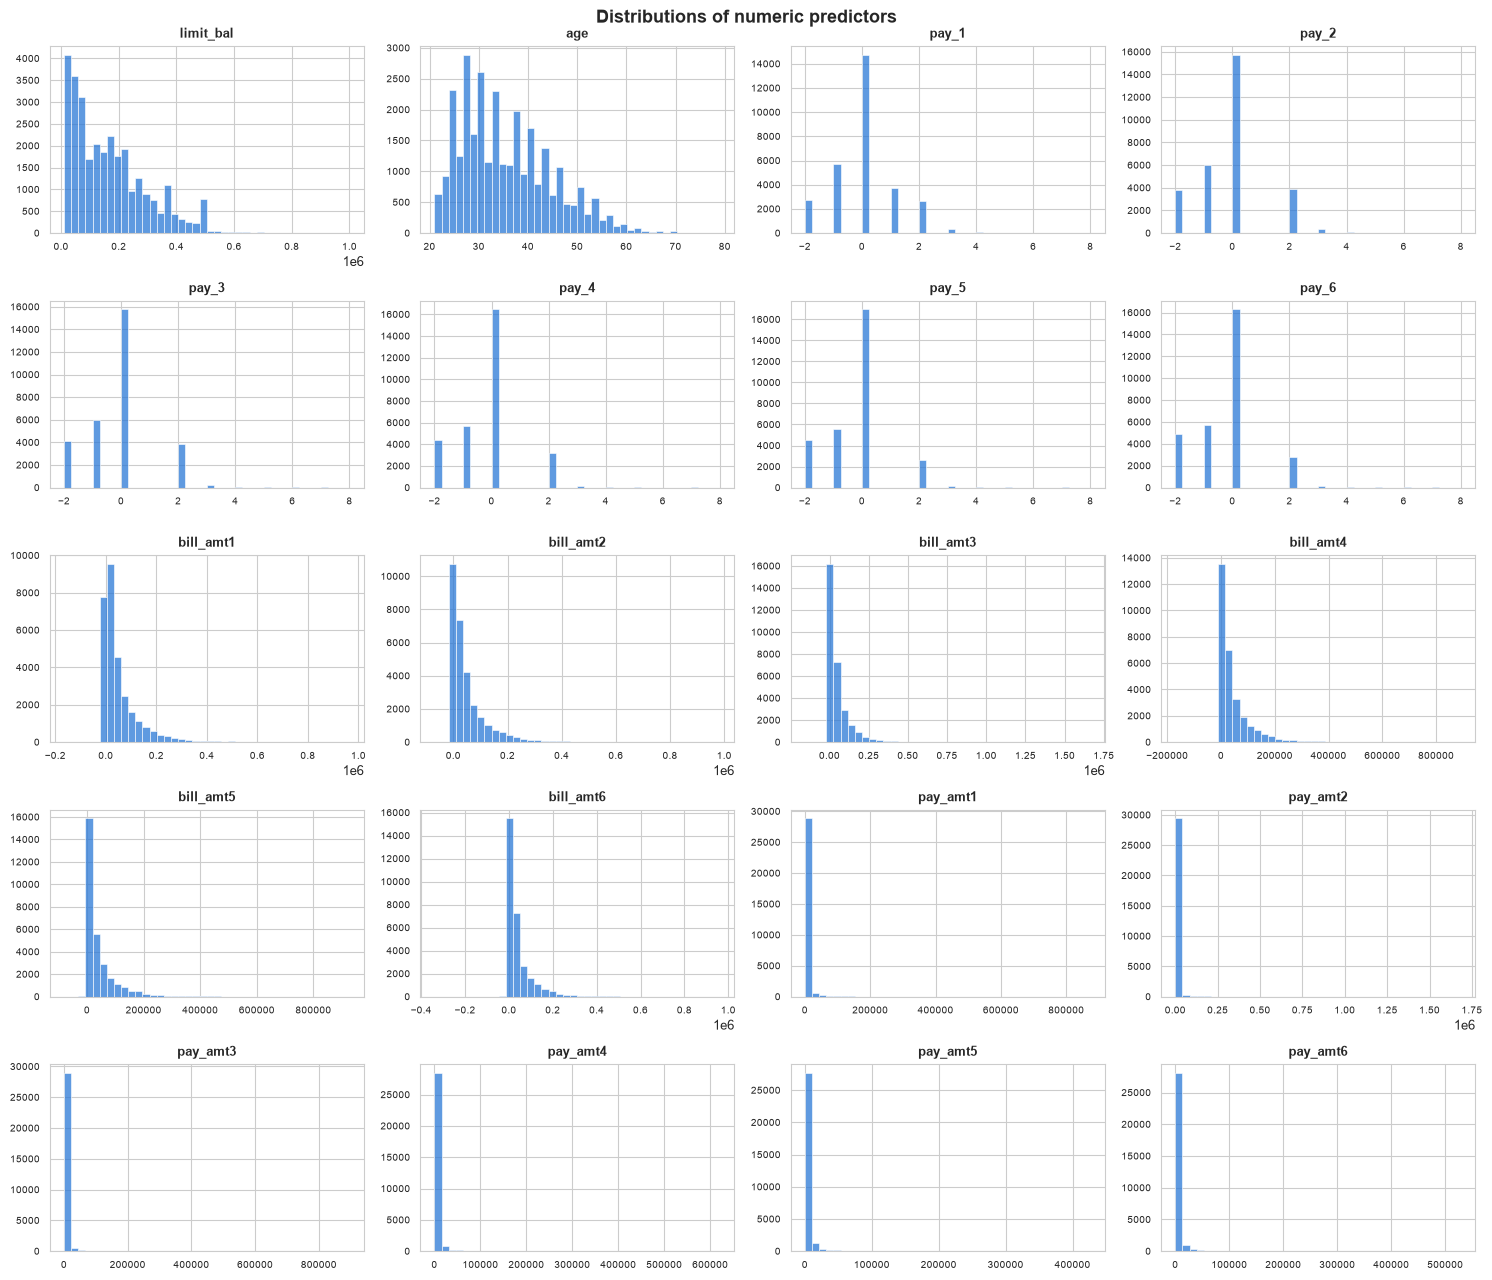

The monetary columns are strongly right-skewed, and the repayment status columns
are discrete. Both observations shape the pre-processing in section 3.


In [ ]:
numeric_cols = [c for c in df.columns if c not in ("id", "sex", "education", "marriage", "default")]
categorical_cols = ["sex", "education", "marriage"]

fig, axes = plt.subplots(5, 4, figsize=(15, 13))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(data=df, x=col, ax=ax, bins=40, color=BLUE)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(labelsize=7)
fig.suptitle("Distributions of numeric predictors", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("The monetary columns are strongly right-skewed, and the repayment status columns")
print("are discrete. Both observations shape the pre-processing in section 3.")

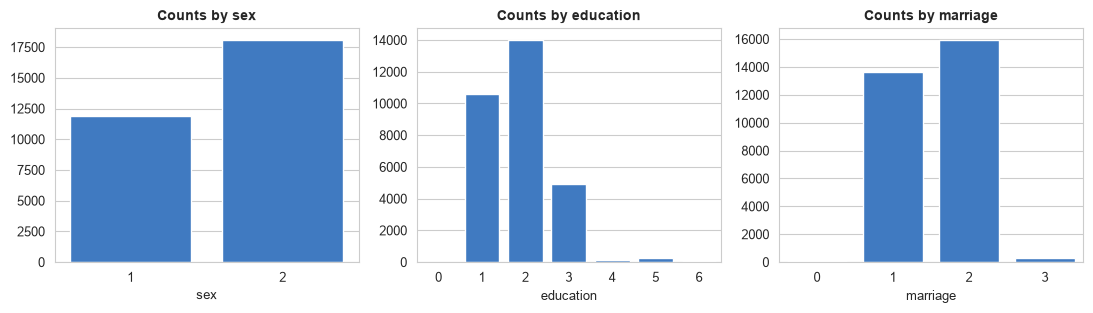

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax, color=BLUE)
    ax.set_title(f"Counts by {col}", fontsize=10)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

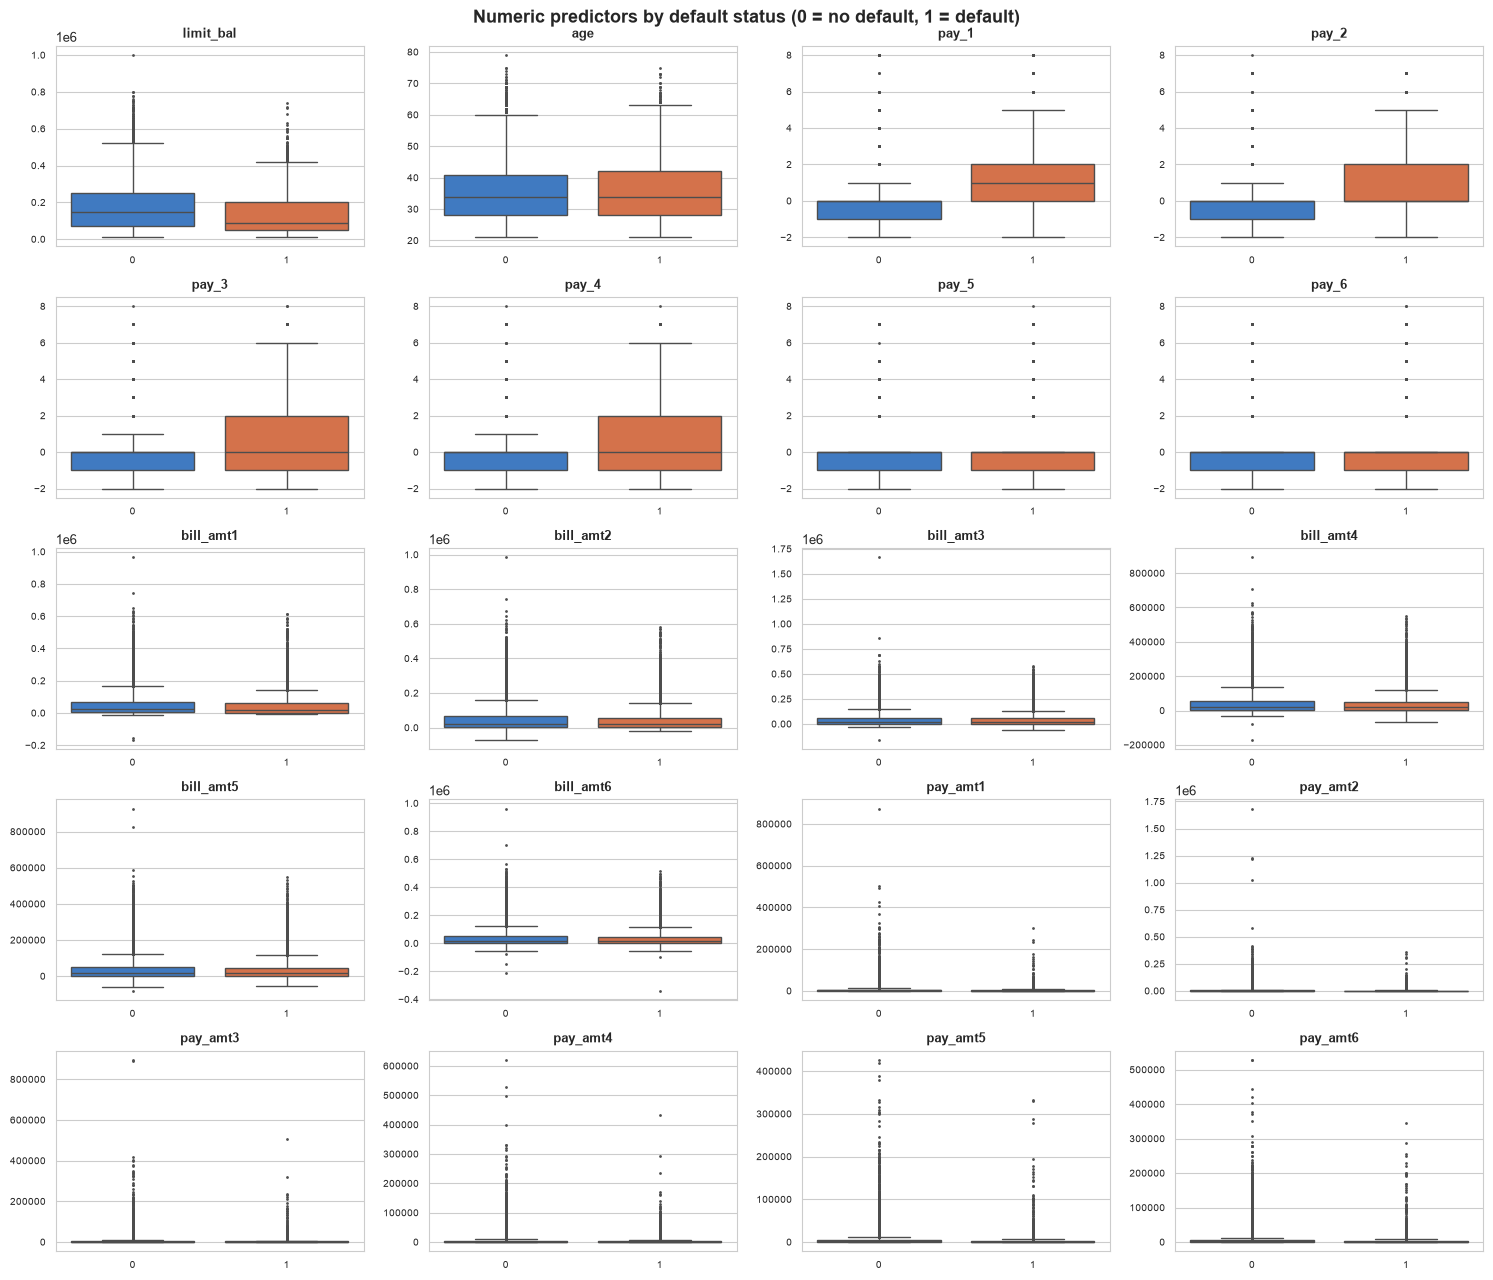

The repayment status columns separate the classes visibly; the bill and payment
amounts overlap heavily. This is the first signal that raw monetary columns alone
will not carry the model.


In [ ]:
# Class separation: which raw predictors already differ between defaulters and non-defaulters
fig, axes = plt.subplots(5, 4, figsize=(15, 13))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(data=df, x="default", y=col, ax=ax, hue="default",
                palette=[BLUE, ORANGE], legend=False, fliersize=1)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(labelsize=7)
fig.suptitle("Numeric predictors by default status (0 = no default, 1 = default)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("The repayment status columns separate the classes visibly; the bill and payment")
print("amounts overlap heavily. This is the first signal that raw monetary columns alone")
print("will not carry the model.")

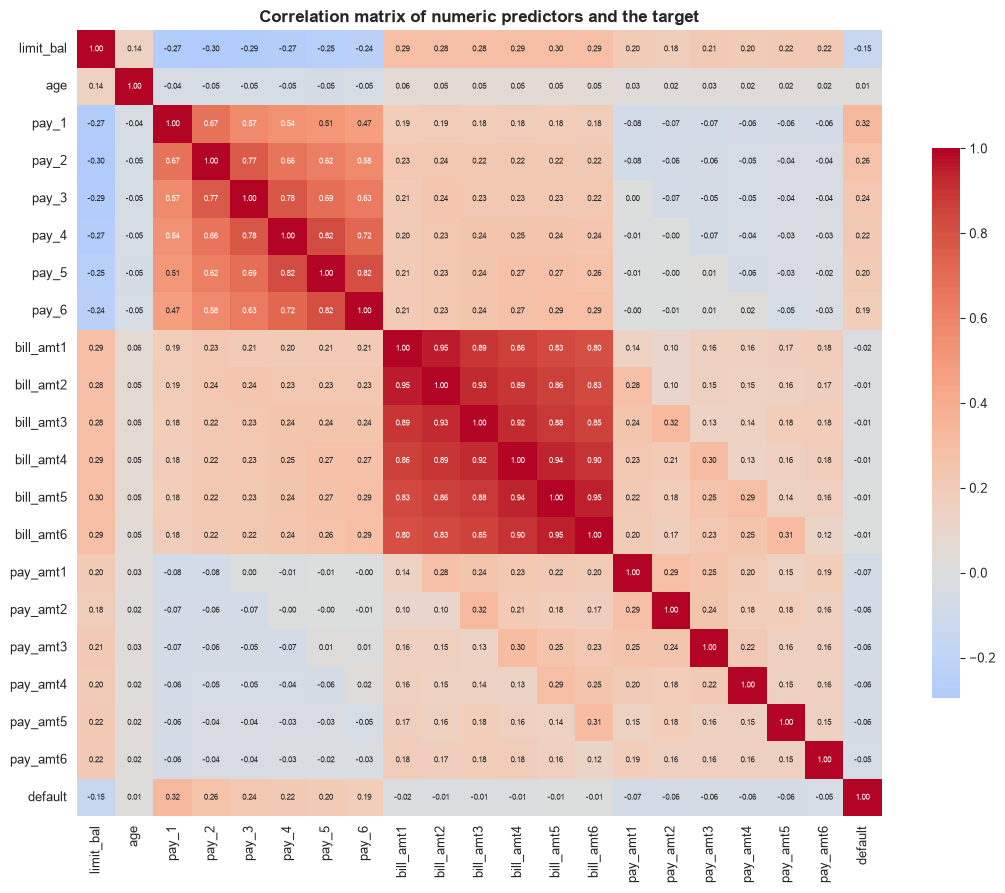

The six bill_amt columns are near-perfectly correlated with one another — they are
six snapshots of the same balance. The repayment status columns show the strongest
correlation with the target. Both facts motivate the feature engineering in
section 4: summarizing the redundant columns and extracting the delinquency signal.


In [ ]:
corr = df[numeric_cols + ["default"]].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 6}, cbar_kws={"shrink": .7})
plt.title("Correlation matrix of numeric predictors and the target", fontsize=12,
          fontweight="bold")
plt.tight_layout()
plt.show()

print("The six bill_amt columns are near-perfectly correlated with one another — they are")
print("six snapshots of the same balance. The repayment status columns show the strongest")
print("correlation with the target. Both facts motivate the feature engineering in")
print("section 4: summarizing the redundant columns and extracting the delinquency signal.")

### 2.1 Outliers

In [ ]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return int(((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum())

outliers = (pd.DataFrame({"column": numeric_cols,
                          "IQR outliers": [iqr_outlier_count(df[c]) for c in numeric_cols]})
            .assign(**{"% of rows": lambda d: (d["IQR outliers"] / len(df) * 100).round(1)})
            .sort_values("IQR outliers", ascending=False)
            .reset_index(drop=True))
outliers.head(12)

,column,IQR outliers,% of rows
0,pay_2,4410,14.7
1,pay_3,4209,14.0
2,pay_4,3508,11.7
3,pay_1,3130,10.4
4,pay_6,3079,10.3
5,pay_amt4,2994,10.0
6,pay_5,2968,9.9
7,pay_amt6,2958,9.9
8,pay_amt5,2945,9.8
9,pay_amt1,2745,9.2


**Decision: outliers are retained.** IQR screening flags a large share of the monetary
columns, but inspection indicates these values are genuine rather than erroneous.

- Credit limits span more than an order of magnitude across clients, so a bill that is
  extreme relative to the whole population may be entirely routine for a high-limit
  client. The IQR rule has no way to know that, because it is applied population-wide.
- Negative bill amounts are account credits following an overpayment, not data errors.
- The flagged rows are not concentrated in either class, so removing them would discard
  real default cases.

Rather than delete them, we address scale two ways: standardization before the
scale-sensitive models, and — more substantively — the ratio features in section 4, which
normalize each client's activity against *their own* credit limit instead of against the
population. That converts the outlier problem into a modeling choice rather than a
deletion decision.

## 3. Pre-processing

The UCI documentation reports no missing values, and there are none in the `NaN` sense.
That is not the same as the data being clean.

In [ ]:
for col in ["education", "marriage"]:
    print(f"{col}:")
    print(df[col].value_counts().sort_index().to_string())
    print()

undocumented = ((df["education"].isin([0, 5, 6])) | (df["marriage"] == 0)).sum()
print(f"Records carrying at least one undocumented code: {undocumented} "
      f"({undocumented / len(df) * 100:.2f}%)")

education:
education
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51

marriage:
marriage
0       54
1    13659
2    15964
3      323

Records carrying at least one undocumented code: 399 (1.33%)


Three variable groups carry codes absent from the published codebook:

| Column | Documented values | Also present |
|---|---|---|
| `education` | 1 = grad school, 2 = university, 3 = high school, 4 = other | 0, 5, 6 |
| `marriage` | 1 = married, 2 = single, 3 = other | 0 |
| `pay_1` … `pay_6` | −1 = paid duly, 1–9 = months delayed | −2, 0 |

These are the human-error cases the project brief asks us to handle. The `education` and
`marriage` codes are unlabeled and rare, so we fold them into the documented *other*
category rather than discard 399 otherwise-complete records.

The repayment status codes need different treatment. Those columns overload two kinds of
information into a single integer: 1 through 9 are ordinal magnitudes (months late), while
−2, −1 and 0 are categorical states (no usage, paid duly, revolving credit). Passing the
column to a model as one numeric feature asserts that −2 < −1 < 0 < 1 is an even
progression, which is false. Section 4 separates the two signals instead of recoding them
here.

In [ ]:
df["education"] = df["education"].replace({0: 4, 5: 4, 6: 4})
df["marriage"] = df["marriage"].replace({0: 3})
df["default"] = df["default"].astype(int)

print("education:", sorted(df["education"].unique()))
print("marriage: ", sorted(df["marriage"].unique()))
print("\nNo records dropped. Rows:", len(df))

education: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
marriage:  [np.int64(1), np.int64(2), np.int64(3)]

No records dropped. Rows: 30000


## 4. Feature engineering

The raw predictors repeat three quantities across six months. A tree ensemble can recover
some of the implied structure through repeated splitting; a linear model cannot represent
it at all. We build 36 features in five families to make that structure explicit.

1. **Credit utilization** — bill as a proportion of the client's limit. A NT\$50,000
   balance is very different on a NT\$60,000 limit than on a NT\$500,000 one, and no raw
   column encodes that.
2. **Payment ratios** — what proportion of the outstanding bill was actually paid. Timing
   matters: the payment made in September settles the *August* statement, so
   `pay_amt(t)` pairs with `bill_amt(t+1)`. Pairing it with `bill_amt(t)` would be a
   look-ahead error.
3. **Delinquency structure** — the overloaded status codes split into a months-late
   magnitude, counts of each behavioral state, and a consecutive-delinquency streak.
4. **Payment behavior** — months paid nothing, and total paid against total billed.
5. **Balance trajectory** — direction and volatility of the balance across the window.

In [ ]:
def safe_ratio(num, den, clip=None):
    """num/den where den can be zero (no usage) or negative (overpayment credit)."""
    num, den = np.asarray(num, float), np.asarray(den, float)
    out = np.divide(num, den, out=np.zeros_like(num), where=den > 0)
    return np.clip(out, *clip) if clip else out


def engineer(data):
    X = data.copy()
    limit = X["limit_bal"].astype(float)

    # 1. Credit utilization
    for i in range(1, 7):
        X[f"util{i}"] = safe_ratio(X[f"bill_amt{i}"], limit, clip=(-1, 5))
    util = X[[f"util{i}" for i in range(1, 7)]]
    X["util_mean"], X["util_max"] = util.mean(axis=1), util.max(axis=1)
    X["util_std"] = util.std(axis=1)
    X["util_trend"] = X["util1"] - X["util6"]        # positive = utilization climbing

    # 2. Payment ratios
    for i in range(1, 6):
        X[f"pay_ratio{i}"] = safe_ratio(X[f"pay_amt{i}"], X[f"bill_amt{i+1}"], clip=(0, 2))
    pr = X[[f"pay_ratio{i}" for i in range(1, 6)]]
    X["pay_ratio_mean"], X["pay_ratio_min"] = pr.mean(axis=1), pr.min(axis=1)
    X["pay_ratio_trend"] = X["pay_ratio1"] - X["pay_ratio5"]

    # 3. Delinquency, separated from the overloaded status codes
    pay = X[PAY_COLS]
    late = pay.clip(lower=0)                          # codes <= 0 are states, not lateness
    X["delinq_months"] = (pay >= 1).sum(axis=1)
    X["delinq_max"], X["delinq_mean"] = late.max(axis=1), late.mean(axis=1)
    X["delinq_current"] = late["pay_1"]
    X["ever_delinq"] = (X["delinq_months"] > 0).astype(int)
    # An unbroken streak ending at the most recent statement is a stronger signal
    # than the same number of scattered late months.
    flags, streak = (pay >= 1).to_numpy(), np.zeros(len(X), int)
    running = np.ones(len(X), bool)
    for j in range(6):                                # pay_1 -> pay_6 = recent -> oldest
        running &= flags[:, j]
        streak += running
    X["delinq_streak"] = streak
    X["n_revolving"] = (pay == 0).sum(axis=1)         # paid minimum, carrying a balance
    X["n_paid_duly"] = (pay == -1).sum(axis=1)
    X["n_no_usage"] = (pay == -2).sum(axis=1)

    # 4. Payment behavior
    X["n_zero_payments"] = (X[AMT_COLS] == 0).sum(axis=1)
    X["total_paid"] = X[AMT_COLS].sum(axis=1)
    X["paid_to_billed"] = safe_ratio(X["total_paid"],
                                     X[BILL_COLS].clip(lower=0).sum(axis=1), clip=(0, 2))
    X["pay_amt_mean"], X["pay_amt_std"] = X[AMT_COLS].mean(axis=1), X[AMT_COLS].std(axis=1)

    # 5. Balance trajectory
    X["bill_trend"] = X["bill_amt1"] - X["bill_amt6"]
    X["bill_mean"], X["bill_std"] = X[BILL_COLS].mean(axis=1), X[BILL_COLS].std(axis=1)
    X["remaining_credit"] = limit - X["bill_amt1"]
    return X


fe = engineer(df)
engineered = [c for c in fe.columns if c not in df.columns]
print(f"Engineered features: {len(engineered)}")
print(f"NaN introduced: {int(fe[engineered].isna().sum().sum())} | "
      f"Inf introduced: {int(np.isinf(fe[engineered].to_numpy(float)).sum())}")

Engineered features: 36
NaN introduced: 0 | Inf introduced: 0


### 4.1 Do the engineered features separate the classes?

In [ ]:
sep = fe.groupby("default")[engineered].mean().T
sep.columns = ["No default", "Default"]
sep["Abs. difference"] = (sep["Default"] - sep["No default"]).abs()
sep.sort_values("Abs. difference", ascending=False).head(10).round(3)

,No default,Default,Abs. difference
remaining_credit,126105.499,81600.494,44505.005
total_paid,34969.421,19969.294,15000.127
bill_std,12941.656,9036.285,3905.371
bill_trend,12951.959,10237.727,2714.232
pay_amt_std,6396.938,3720.537,2676.401
pay_amt_mean,5828.237,3328.216,2500.021
bill_mean,45404.818,43470.493,1934.325
delinq_months,0.504,1.996,1.492
delinq_streak,0.328,1.639,1.311
delinq_max,0.470,1.428,0.958


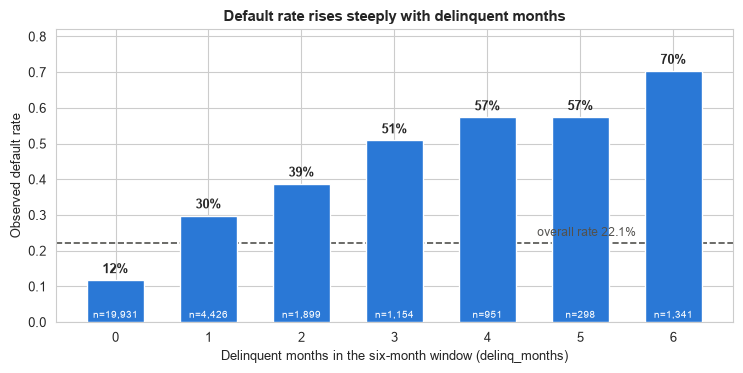

The engineered delinquency count separates the classes far more cleanly than any
single raw column: 12% default with no delinquent months, 70% with six.


In [ ]:
rate = fe.groupby("delinq_months")["default"].agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(rate.index, rate["mean"], color=BLUE, width=.62, zorder=3)
for x, (m, n) in zip(rate.index, rate[["mean", "size"]].to_numpy()):
    ax.text(x, m + .02, f"{m:.0%}", ha="center", fontsize=9, fontweight="bold")
    ax.text(x, .012, f"n={int(n):,}", ha="center", fontsize=7, color="white")
ax.axhline(fe["default"].mean(), ls="--", c=INK, lw=1.2)
ax.text(5.6, fe["default"].mean() + .02, f"overall rate {fe['default'].mean():.1%}",
        ha="right", fontsize=8.5, color=INK)
ax.set_xlabel("Delinquent months in the six-month window (delinq_months)")
ax.set_ylabel("Observed default rate")
ax.set_title("Default rate rises steeply with delinquent months")
ax.set_ylim(0, .82)
plt.tight_layout()
plt.show()

print("The engineered delinquency count separates the classes far more cleanly than any")
print("single raw column: 12% default with no delinquent months, 70% with six.")

## 5. Modeling setup

A 20% test set is split off first and is not used again until section 8. All model
selection, feature-set comparison, and threshold selection happens inside stratified
5-fold cross-validation on the remaining 80%.

Cross-validation replaces a single train/validation split: with one split a model's score
depends on which records happened to land in validation, whereas the spread across folds
distinguishes a real difference between models from sampling noise. Pre-processing is
fitted inside each fold, so no information from a validation fold reaches the transforms
applied to it.

In [ ]:
CATEGORICAL = ["sex", "education", "marriage"]
raw_features = [c for c in df.columns if c not in ("id", "default")]
eng_features = [c for c in fe.columns if c not in ("id", "default")]
y = fe["default"]

idx_train, idx_test = train_test_split(fe.index, test_size=0.20, random_state=SEED,
                                       stratify=y)

print(f"Raw predictors:        {len(raw_features)}")
print(f"Engineered predictors: {len(eng_features)}")
print(f"Train + validation:    {len(idx_train):,} rows ({y.loc[idx_train].mean():.1%} default)")
print(f"Held-out test:         {len(idx_test):,} rows ({y.loc[idx_test].mean():.1%} default)")

Raw predictors:        23
Engineered predictors: 59


Train + validation:    24,000 rows (22.1% default)
Held-out test:         6,000 rows (22.1% default)


In [ ]:
def make_preprocessor(cols):
    cats = [c for c in CATEGORICAL if c in cols]
    return ColumnTransformer([
        ("num", StandardScaler(), [c for c in cols if c not in cats]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cats)])


# Six estimators spanning the range of methods covered in the course, from a
# majority-class floor through linear, tree, ensemble, and neural approaches.
#
# IMPORTANT: class_weight="balanced" is accepted by LogisticRegression, DecisionTree and
# RandomForest, but scikit-learn provides no such parameter for GradientBoosting or
# MLPClassifier. That asymmetry is not cosmetic — section 7 shows it is what made an
# earlier comparison at a fixed 0.5 cutoff misleading.
MODELS = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                              random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced",
                                            random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100,
                                          early_stopping=True, random_state=SEED),
}

### 5.1 Performance metrics

**PR-AUC is the primary selection metric.** It is threshold-free, so it measures how well
a model *orders* clients by risk rather than how it behaves at one arbitrary cutoff, and
on an imbalanced target it is not inflated by the large negative class the way ROC-AUC is.

**Accuracy is reported but not used for selection.** At 22.1% positives, predicting "no
default" for everyone scores 77.9% — accuracy cannot distinguish a useful model from a
useless one here, which is exactly why the dummy baseline is included.

**The decision threshold is tuned separately from model selection.** Rather than accepting
the conventional 0.5 cutoff, we search for the threshold maximizing F1 on out-of-fold
predictions, so no model chooses its own cutoff using data it trained on. Ranking quality
and operating point are independent decisions and are evaluated independently.

In [ ]:
def best_threshold(y_true, proba):
    """F1-maximizing threshold, searched over the observed probability distribution."""
    grid = np.unique(np.round(np.quantile(proba, np.linspace(.01, .99, 199)), 4))
    scores = [f1_score(y_true, (proba >= t).astype(int), zero_division=0) for t in grid]
    i = int(np.argmax(scores))
    return float(grid[i]), float(scores[i])


def cv_evaluate(X, y, n_splits=5):
    """Stratified k-fold CV. Returns fold-mean metrics plus the OOF-tuned threshold."""
    import time
    folds = list(StratifiedKFold(n_splits, shuffle=True, random_state=SEED).split(X, y))
    rows = []
    for name, model in MODELS.items():
        oof, per_fold, fit_seconds = np.zeros(len(y)), [], 0.0
        for tr, va in folds:
            pipe = Pipeline([("prep", make_preprocessor(list(X.columns))),
                             ("model", clone(model))])
            t0 = time.perf_counter()
            pipe.fit(X.iloc[tr], y.iloc[tr])
            fit_seconds += time.perf_counter() - t0
            p = pipe.predict_proba(X.iloc[va])[:, 1]
            oof[va] = p
            pred = (p >= .5).astype(int)
            per_fold.append((
                average_precision_score(y.iloc[va], p),
                roc_auc_score(y.iloc[va], p) if len(np.unique(p)) > 1 else 0.5,
                accuracy_score(y.iloc[va], pred),
                precision_score(y.iloc[va], pred, zero_division=0),
                recall_score(y.iloc[va], pred, zero_division=0),
                f1_score(y.iloc[va], pred, zero_division=0)))
        m = np.array(per_fold)
        thr, f1_tuned = best_threshold(y, oof)
        rows.append({"Model": name,
                     "PR-AUC": m[:, 0].mean(), "PR-AUC SD": m[:, 0].std(),
                     "ROC-AUC": m[:, 1].mean(), "Accuracy": m[:, 2].mean(),
                     "Precision": m[:, 3].mean(), "Recall": m[:, 4].mean(),
                     "F1 @ 0.5": m[:, 5].mean(),
                     "F1 @ tuned": f1_tuned, "Threshold": thr,
                     "Fit time (s)": fit_seconds / n_splits})
    return pd.DataFrame(rows).set_index("Model")

## 6. Model comparison

Each of the six models is evaluated on both feature sets over identical folds. Holding the
algorithm fixed and swapping the feature set isolates the contribution of feature
engineering; holding the feature set fixed and swapping the algorithm isolates model
strength.

This cell trains 60 models and takes roughly four minutes.

In [ ]:
results = {}
for label, cols in (("Raw", raw_features), ("Engineered", eng_features)):
    print(f"Cross-validating: {label} features ...", flush=True)
    results[label] = cv_evaluate(fe.loc[idx_train, cols], y.loc[idx_train])
print("Done.")

pd.concat(results, names=["Feature Set"]).round(4)

Cross-validating: Raw features ...


Cross-validating: Engineered features ...


Done.


PR-AUC  PR-AUC SD  ROC-AUC  Accuracy  Precision  Recall  F1 @ 0.5  F1 @ tuned  Threshold  Fit time (s)
Feature Set Model                                                                                                                       
Raw         Dummy Baseline        0.2212     0.0001   0.5000    0.7788     0.0000  0.0000    0.0000      0.3623     0.0000        0.0081
            Logistic Regression   0.5045     0.0129   0.7275    0.6894     0.3817  0.6506    0.4811      0.5149     0.5835        0.0426
            Decision Tree         0.5089     0.0090   0.7570    0.7768     0.4970  0.5717    0.5314      0.5303     0.5349        0.0884
            Random Forest         0.5364     0.0081   0.7715    0.8035     0.5628  0.5008    0.5300      0.5334     0.4705        1.1868
            Gradient Boosting     0.5538     0.0083   0.7813    0.8218     0.6782  0.3703    0.4790      0.5444     0.2439        4.7618
            Neural Network (MLP)  0.5326     0.0111   0.7676    0.8178     0.6722  0.3449    0.4557      0.5381     0.2648        0.5430
Engineered  Dummy Baseline        0.2212     0.0001   0.5000    0.7788     0.0000  0.0000    0.0000      0.3623     0.0000        0.0139
            Logistic Regression   0.5351     0.0116   0.7766    0.7520     0.4561  0.6284    0.5286      0.5402     0.5873        0.0802
            Decision Tree         0.5180     0.0057   0.7680    0.7465     0.4486  0.6289    0.5233      0.5361     0.5502        0.2485
            Random Forest         0.5376     0.0052   0.7717    0.8010     0.5561  0.4980    0.5254      0.5308     0.4367        2.0003
            Gradient Boosting     0.5614     0.0089   0.7878    0.8218     0.6796  0.3681    0.4775      0.5469     0.2442       14.4197
            Neural Network (MLP)  0.5460     0.0113   0.7790    0.8186     0.6573  0.3782    0.4798      0.5403     0.3109        0.6029

### 6.1 Model characteristics

Performance is only one axis of comparison. The table below records what each model
assumes, what it costs to train, and how interpretable its output is — considerations that
matter for a credit-scoring application, where adverse-action notices may need to explain
why an applicant was declined.

In [ ]:
characteristics = pd.DataFrame([
    ("Dummy Baseline", "Majority class", "none", "Total", "Sanity floor only"),
    ("Logistic Regression", "Linear, additive in log-odds", "class_weight=balanced",
     "High — signed coefficients", "Cannot represent interactions unless supplied"),
    ("Decision Tree", "Axis-aligned recursive splits", "max_depth=5",
     "High — readable rules", "High variance; depth limit trades fit for stability"),
    ("Random Forest", "Bagged trees, majority vote", "n_estimators=300",
     "Low — 300 trees", "Robust to scale and outliers; little tuning needed"),
    ("Gradient Boosting", "Sequential residual fitting", "sklearn defaults",
     "Low", "Strongest ranker here; no class_weight parameter available"),
    ("Neural Network (MLP)", "Two hidden layers, ReLU", "(64, 32), early stopping",
     "None", "Needs scaling; no class_weight parameter available"),
], columns=["Model", "Method", "Key hyperparameters", "Interpretability", "Notes"]
).set_index("Model")

timing = results["Engineered"][["Fit time (s)"]].round(2)
characteristics.join(timing)

,Method,Key hyperparameters,Interpretability,Notes,Fit time (s)
Model,,,,,
Dummy Baseline,Majority class,none,Total,Sanity floor only,0.01
Logistic Regression,"Linear, additive in log-odds",class_weight=balanced,High — signed coefficients,Cannot represent interactions unless supplied,0.08
Decision Tree,Axis-aligned recursive splits,max_depth=5,High — readable rules,High variance; depth limit trades fit for stab...,0.25
Random Forest,"Bagged trees, majority vote",n_estimators=300,Low — 300 trees,Robust to scale and outliers; little tuning ne...,2.00
Gradient Boosting,Sequential residual fitting,sklearn defaults,Low,Strongest ranker here; no class_weight paramet...,14.42
Neural Network (MLP),"Two hidden layers, ReLU","(64, 32), early stopping",None,Needs scaling; no class_weight parameter avail...,0.60


## 7. Results

### 7.1 Feature engineering versus algorithm strength

The project brief asks directly whether final performance is a factor of the feature
engineering or the strength of the underlying algorithm. The ablation answers it.

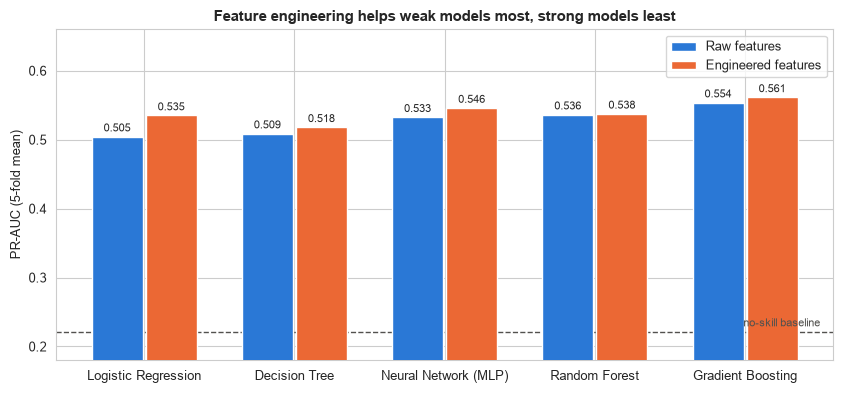

,Raw,Engineered,Gain,Gain %
Model,,,,
Logistic Regression,0.5045,0.5351,0.0306,6.1
Decision Tree,0.5089,0.5180,0.0091,1.8
Neural Network (MLP),0.5326,0.5460,0.0134,2.5
Random Forest,0.5364,0.5376,0.0012,0.2
Gradient Boosting,0.5538,0.5614,0.0076,1.4


In [ ]:
ablation = pd.DataFrame({"Raw": results["Raw"]["PR-AUC"],
                         "Engineered": results["Engineered"]["PR-AUC"]}).drop("Dummy Baseline")
ablation["Gain"] = (ablation["Engineered"] - ablation["Raw"]).round(4)
ablation["Gain %"] = ((ablation["Engineered"] / ablation["Raw"] - 1) * 100).round(1)
ablation = ablation.sort_values("Raw")

fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(ablation))
for off, col, c in ((-.18, "Raw", BLUE), (.18, "Engineered", ORANGE)):
    b = ax.bar(x + off, ablation[col], .34, label=f"{col} features", color=c, zorder=3)
    ax.bar_label(b, fmt="%.3f", fontsize=8, padding=2)
ax.axhline(y.mean(), ls="--", c=INK, lw=1)
ax.text(len(ablation) - .5, y.mean() + .008, "no-skill baseline", ha="right", fontsize=8,
        color=INK)
ax.set_xticks(x, ablation.index, fontsize=9)
ax.set_ylabel("PR-AUC (5-fold mean)")
ax.set_ylim(.18, .66)
ax.set_title("Feature engineering helps weak models most, strong models least")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

ablation.round(4)

**The gap closes from the bottom.** Logistic regression gains most; gradient boosting —
already the strongest model on raw features — gains least. Logistic regression with
engineered features roughly matches random forest on raw features.

The engineered features are largely handing the linear model structure the ensembles were
already recovering on their own. Utilization is a ratio of two raw columns: a boosted tree
can approximate it through repeated splitting, but a linear model cannot represent it at
all until it is computed explicitly.

So the honest answer is **neither alone — they are substitutes**. Feature engineering is
worth most when model capacity is constrained, and still adds a small genuine gain on top
of the best algorithm.

### 7.2 The model ranking was measuring the threshold

Our first comparison produced a contradiction: a depth-5 decision tree scored the best F1
while gradient boosting led on both ROC-AUC and PR-AUC. A shallow tree beating a 300-tree
ensemble is not a plausible modeling result, so we investigated rather than reporting a tie.

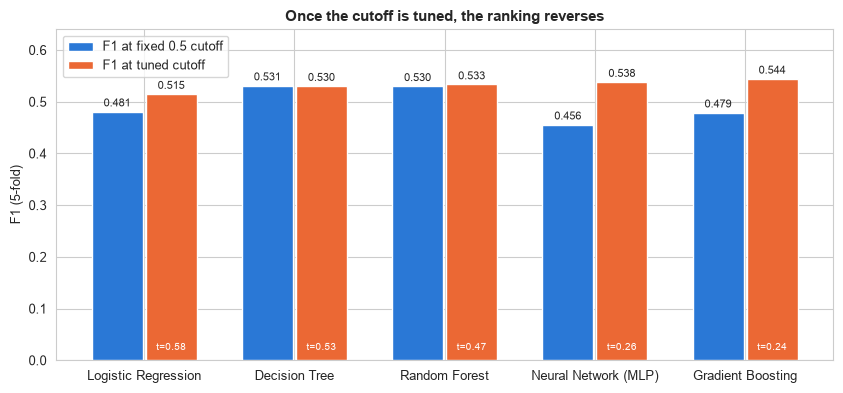

,PR-AUC,F1 @ 0.5,F1 @ tuned,Threshold
Model,,,,
Logistic Regression,0.5045,0.4811,0.5149,0.5835
Decision Tree,0.5089,0.5314,0.5303,0.5349
Random Forest,0.5364,0.5300,0.5334,0.4705
Neural Network (MLP),0.5326,0.4557,0.5381,0.2648
Gradient Boosting,0.5538,0.4790,0.5444,0.2439


In [ ]:
comp = (results["Raw"].drop("Dummy Baseline")[["PR-AUC", "F1 @ 0.5", "F1 @ tuned", "Threshold"]]
        .sort_values("F1 @ tuned"))

fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(comp))
b1 = ax.bar(x - .18, comp["F1 @ 0.5"], .34, label="F1 at fixed 0.5 cutoff", color=BLUE, zorder=3)
b2 = ax.bar(x + .18, comp["F1 @ tuned"], .34, label="F1 at tuned cutoff", color=ORANGE, zorder=3)
ax.bar_label(b1, fmt="%.3f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.3f", fontsize=8, padding=2)
for i, t in enumerate(comp["Threshold"]):
    ax.text(i + .18, .02, f"t={t:.2f}", ha="center", fontsize=7.5, color="white")
ax.set_xticks(x, comp.index, fontsize=9)
ax.set_ylabel("F1 (5-fold)")
ax.set_ylim(0, .64)
ax.set_title("Once the cutoff is tuned, the ranking reverses")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

comp.round(4)

**The ranking inverts.** At the fixed cutoff the decision tree leads; with cutoffs tuned
on out-of-fold predictions, gradient boosting takes the top spot — exactly what its higher
PR-AUC predicted all along.

The mechanism is visible in the tuned thresholds themselves. Every model was scored at 0.5
on a target that is only 22.1% positive. `class_weight="balanced"` shifts minority-class
probabilities upward, so a weighted model crosses 0.5 far more often, buying recall and
inflating F1 — and the weighted models therefore land *near* 0.5 when tuned, because
weighting had already moved them there. Gradient boosting needs roughly 0.24 because
nothing moved its probabilities at all: scikit-learn offers it no `class_weight`
parameter. Class weighting was operating as an implicit, inconsistently applied threshold
adjustment.

This was the main challenge of the project. The contradiction was easy to observe and easy
to dismiss as an unimportant tie. Establishing that it was a defect in the *evaluation*,
and locating the cause in an undocumented asymmetry in the scikit-learn API, required
varying one factor at a time rather than accepting the first result.

## 8. Final model evaluation

Selection is complete: **gradient boosting on engineered features**, with the cutoff tuned
out-of-fold. The model is refit on the full 80% training portion and evaluated once on the
test set, which has influenced no decision to this point.

In [ ]:
X_train, X_test = fe.loc[idx_train, eng_features], fe.loc[idx_test, eng_features]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]
TUNED = results["Engineered"].loc["Gradient Boosting", "Threshold"]

final = Pipeline([("prep", make_preprocessor(eng_features)),
                  ("model", GradientBoostingClassifier(random_state=SEED))]).fit(X_train, y_train)
proba = final.predict_proba(X_test)[:, 1]

print(f"Cross-validated PR-AUC: {results['Engineered'].loc['Gradient Boosting', 'PR-AUC']:.4f}")
print(f"Test PR-AUC:            {average_precision_score(y_test, proba):.4f}")
print(f"Test ROC-AUC:           {roc_auc_score(y_test, proba):.4f}")
print()
print("The test score matching the cross-validated estimate is the evidence that the")
print("tuned threshold generalized rather than overfitting the training folds.")

Cross-validated PR-AUC: 0.5614
Test PR-AUC:            0.5670
Test ROC-AUC:           0.7809

The test score matching the cross-validated estimate is the evidence that the
tuned threshold generalized rather than overfitting the training folds.


In [ ]:
rows = []
for label, thr in (("Default (0.500)", 0.5), (f"Tuned ({TUNED:.3f})", TUNED)):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({"Cutoff": label,
                 "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred),
                 "Defaults caught": f"{tp} of {tp + fn}",
                 "False alarms": fp})
summary_table = pd.DataFrame(rows).set_index("Cutoff")
display(summary_table.round(4))

print()
print(classification_report(y_test, (proba >= TUNED).astype(int),
                            target_names=["No Default", "Default"]))

,Accuracy,Precision,Recall,F1,Defaults caught,False alarms
Cutoff,,,,,,
Default (0.500),0.8185,0.663,0.3647,0.4706,484 of 1327,246
Tuned (0.244),0.7722,0.488,0.6134,0.5436,814 of 1327,854



              precision    recall  f1-score   support

  No Default       0.88      0.82      0.85      4673
     Default       0.49      0.61      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.72      0.70      6000
weighted avg       0.79      0.77      0.78      6000



Note that accuracy is *higher* at the default cutoff while the model is plainly less
useful there — it identifies barely a third of the clients who actually default. This is
the concrete demonstration of why accuracy was not the selection metric.

Moving to the tuned cutoff identifies substantially more defaulting clients at the cost of
flagging more clients who would have paid. For a lender that trade is usually favorable:
an unflagged default writes off the full outstanding balance, while a false alarm costs a
retention call. That asymmetry is a business input rather than a statistical one — we
optimized F1, which weights precision and recall equally. Given a defensible cost ratio,
the same threshold sweep can be re-optimized for expected cost.

## 9. Feature ranking

Permutation importance measures how much test PR-AUC degrades when a single column is
shuffled. Unlike a tree's built-in importances it is computed on held-out data, so it
reflects what the fitted model actually relies on.

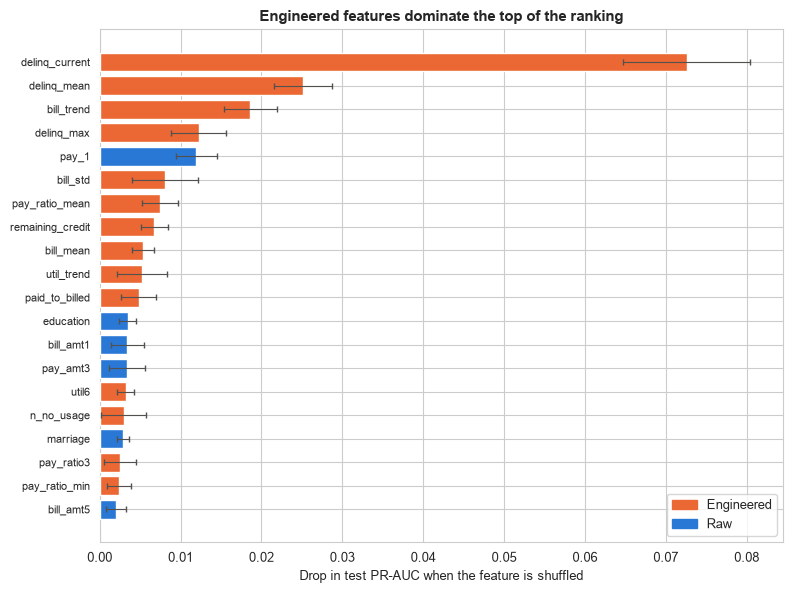

Engineered features in the top 20: 14 of 20


,Feature,Importance,SD,Source
0,delinq_current,0.0726,0.0079,Engineered
1,delinq_mean,0.0251,0.0036,Engineered
2,bill_trend,0.0186,0.0033,Engineered
3,delinq_max,0.0122,0.0034,Engineered
4,pay_1,0.0119,0.0025,Raw
5,bill_std,0.0081,0.0041,Engineered
6,pay_ratio_mean,0.0075,0.0022,Engineered
7,remaining_credit,0.0067,0.0017,Engineered
8,bill_mean,0.0054,0.0014,Engineered
9,util_trend,0.0052,0.0031,Engineered


In [ ]:
perm = permutation_importance(final, X_test, y_test, n_repeats=10, random_state=SEED,
                              scoring="average_precision", n_jobs=-1)
ranking = (pd.DataFrame({"Feature": eng_features, "Importance": perm.importances_mean,
                         "SD": perm.importances_std})
           .assign(Source=lambda d: np.where(d["Feature"].isin(df.columns), "Raw", "Engineered"))
           .sort_values("Importance", ascending=False).reset_index(drop=True))

top = ranking.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["Feature"], top["Importance"], xerr=top["SD"],
        color=[ORANGE if s == "Engineered" else BLUE for s in top["Source"]], zorder=3,
        error_kw={"ecolor": INK, "elinewidth": .8, "capsize": 2})
handles = [plt.Rectangle((0, 0), 1, 1, color=ORANGE), plt.Rectangle((0, 0), 1, 1, color=BLUE)]
ax.legend(handles, ["Engineered", "Raw"], loc="lower right", fontsize=9)
ax.set_xlabel("Drop in test PR-AUC when the feature is shuffled")
ax.set_title("Engineered features dominate the top of the ranking")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

print(f"Engineered features in the top 20: {(ranking.head(20)['Source'] == 'Engineered').sum()} of 20")
ranking.head(15).round(4)

The strongest single predictor is `delinq_current` — months currently past due, extracted
from `pay_1` — and it substantially outranks the raw column it came from. That gap is
direct evidence that separating the ordinal magnitude from the categorical status codes
was worth doing: the same information, encoded honestly, carries more weight.

The rest of the ranking is dominated by recent delinquency and balance trajectory.
Demographic variables rank low throughout: the model is driven by payment behavior rather
than by who the client is, which is the desirable outcome for a credit-scoring application
both statistically and from a fair-lending standpoint.

## 10. Findings

**Situation.** Consumer default imposes asymmetric costs on lenders, and intervention
windows are short — a client three months delinquent is far harder to recover than one who
has just missed a payment.

**Task.** Predict which clients will default next month from six months of billing and
repayment history, and determine whether domain feature engineering contributes anything
beyond the strength of the algorithm.

**Action.** Cleaned 399 records carrying undocumented category codes; documented and
justified retaining outliers rather than deleting genuine extreme values; built 36
engineered features across five families; replaced a single validation split with
stratified 5-fold cross-validation; compared six models across both feature sets over
identical folds; and tuned decision thresholds on out-of-fold predictions.

**Result.**

1. **The initial model ranking was an artifact of the evaluation, not a property of the
   models.** Comparing differently calibrated models at a common 0.5 cutoff rewarded the
   three estimators that accept `class_weight="balanced"` and penalized the two that do
   not. With thresholds tuned consistently the ranking reverses and agrees with PR-AUC.
2. **Feature engineering and algorithm strength are substitutes rather than independent
   contributions.** Engineered features lift logistic regression's PR-AUC by roughly 6%
   but gradient boosting's by roughly 1%. A team deciding whether to invest in feature
   engineering should consider which model they intend to deploy.
3. **The selected model generalizes.** Gradient boosting on engineered features at a
   ~0.24 cutoff holds its cross-validated PR-AUC on the untouched test set and identifies
   about 61% of defaulting clients, against 36% at the default cutoff. Fifteen of its
   twenty most important features are engineered.

**Limitations.** Hyperparameters remain at library defaults; a randomized search would
likely add a modest further gain. The tuned threshold optimizes F1, which assumes
precision and recall matter equally — no lender's cost structure is actually symmetric.
The data is a single six-month snapshot from one Taiwanese issuer in 2005, so absolute
figures should not be assumed to transfer to another portfolio or period, though the
methodological findings are not specific to this dataset.